### Vectorless RAG

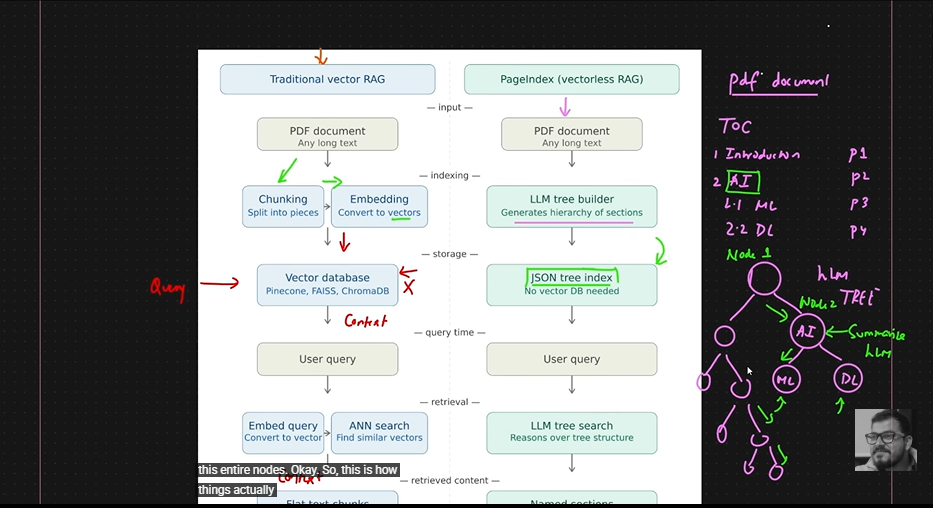

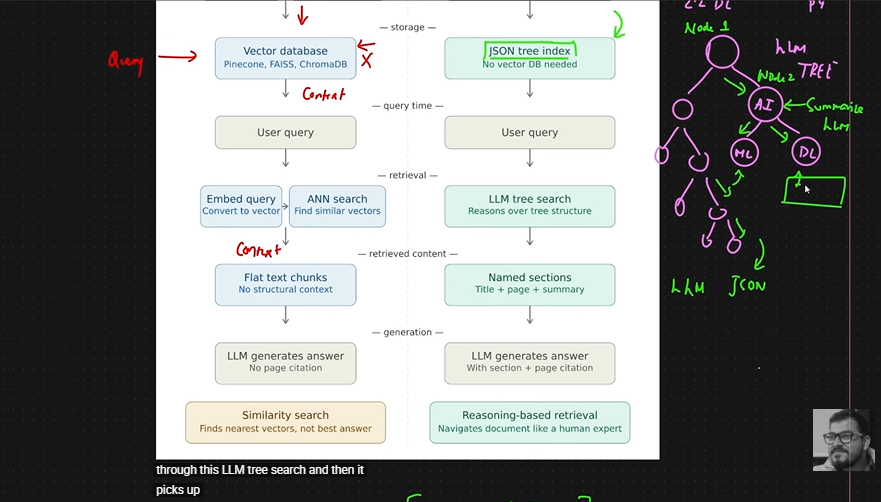

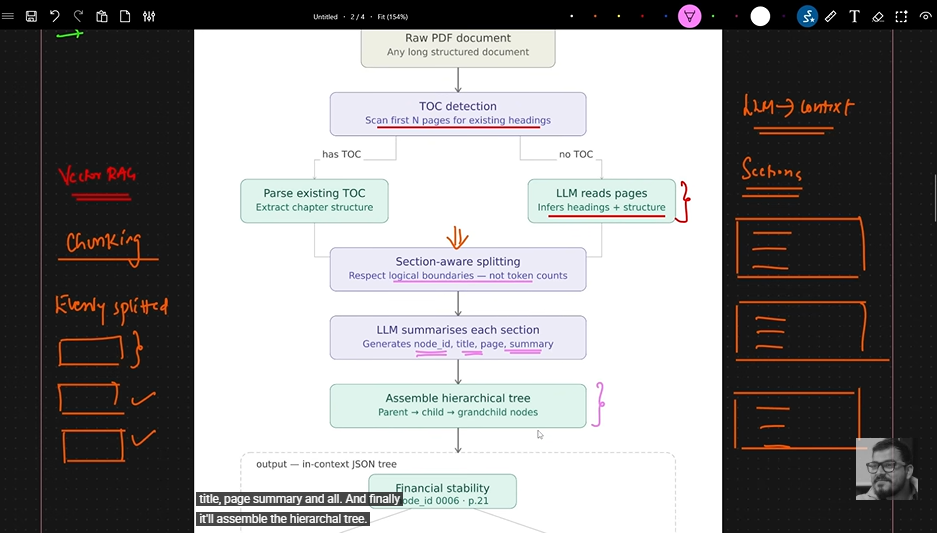
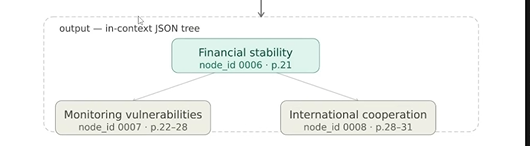


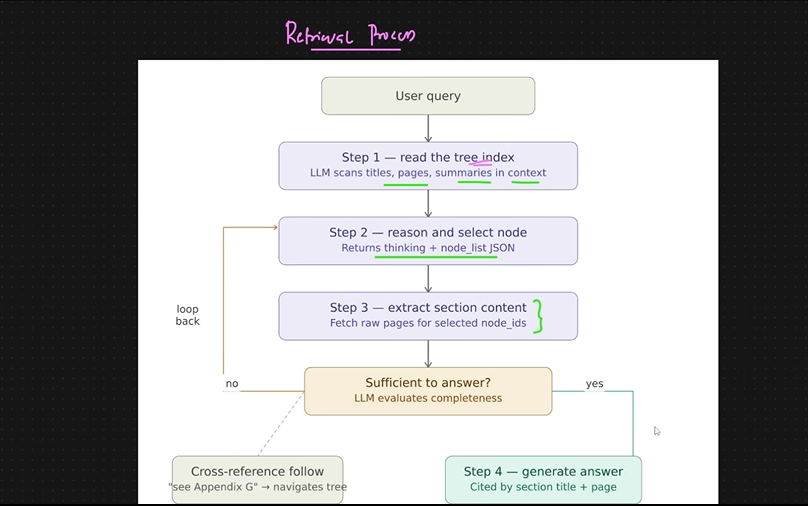



https://github.com/centralkindom1/DeepSeek-VectifyAI-PageIndex

important repo 

https://github.com/krishnaik06/RAG-Tutorials/blob/main/PageIndex_Vectorless_RAG_CrashCourse%20(1).ipynb

In [1]:
import os, json, time
from dotenv import load_dotenv

load_dotenv()

PageIndex_API_KEY = "6cb1ef95a7d846c5900f35423cfdfb92"
Groq_API_KEY    = os.getenv("Groq_API_KEY")

print("PageIndex key loaded:", "✅" if PageIndex_API_KEY else "❌ Missing!")
print("Groq key loaded:   ", "✅" if Groq_API_KEY    else "❌ Missing!")

PageIndex key loaded: ✅
Groq key loaded:    ✅


In [2]:
from pageindex import PageIndexClient   
from groq import Groq

pi_client = PageIndexClient(api_key=PageIndex_API_KEY)
openai_client = Groq(api_key=Groq_API_KEY)

print("✅ PageIndex client ready")
print("✅ OpenAI client ready")

✅ PageIndex client ready
✅ OpenAI client ready


🌲 Section 2: Upload & Index a PDF
What happens here:

1) Upload your PDF to the PageIndex cloud
2) PageIndex uses an LLM to read the document structure
3) Builds a hierarchical tree index (like a smart Table of Contents)
4) Returns a doc_id for all future operations


Why NO chunking?
Instead of cutting the document into arbitrary 500-token pieces, PageIndex respects the document's natural section boundaries — chapters, sub-sections, paragraphs — as the author intended.

In [3]:
# ── Upload your PDF ─────────────────────────────────────────────────────────
# Replace with the path to your PDF file
# Great candidates: Annual reports, research papers, legal docs, textbooks

PDF_PATH = "../RAG/data/text_files/Aryendra Pandey Internship.pdf"   # ← change this

print(f"📤 Uploading: {PDF_PATH}")
result = pi_client.submit_document(PDF_PATH)
doc_id = result["doc_id"]

print(f"✅ Uploaded!")
print(f"📋 Document ID: {doc_id}")
print("   (Save this ID — you'll use it throughout the notebook)")

📤 Uploading: ../RAG/data/text_files/Aryendra Pandey Internship.pdf
✅ Uploaded!
📋 Document ID: pi-cmr88s53e00jq01o32nk4obcd
   (Save this ID — you'll use it throughout the notebook)


Document ID: pi-cmr87w6yq00jl01o3p9lqlkmi

In [4]:
# ── Poll until processing is complete ───────────────────────────────────────
# PageIndex builds the tree asynchronously.
# For a 50-page PDF this typically takes 30–90 seconds.

print("⏳ Building tree index...")
print("   (This runs once per document — the index is cached for reuse)")

while True:
    status_result = pi_client.get_document(doc_id)
    status = status_result.get("status")
    print(f"   Status: {status}")
    
    if status == "completed":
        print("\n✅ Tree index ready!")
        break
    elif status == "failed":
        print("\n❌ Processing failed. Check your PDF format.")
        break
    
    time.sleep(5)

⏳ Building tree index...
   (This runs once per document — the index is cached for reuse)
   Status: processing
   Status: processing
   Status: completed

✅ Tree index ready!


🔍 Section 3: Inspect the Tree Structure
What the tree looks like:

Document
├── Introduction (pages 1-3)
│   └── Background (pages 1-2)
├── Financial Stability (pages 21-31)
│   ├── Monitoring Vulnerabilities (pages 22-28)
│   └── International Cooperation (pages 28-31)
└── Conclusion (pages 45-47)
Each node has:

1) node_id — unique ID used during retrieval
2) title — section heading
3) page_index — page number in original PDF
4) text — section summary (when node_summary=True)
5) nodes — child sections (nested)

This structure is what the LLM reasons over during retrieval.

In [5]:
# ── Fetch the full tree ─────────────────────────────────────────────────────
tree_result  = pi_client.get_tree(doc_id, node_summary=True)
pageindex_tree = tree_result.get("result", [])

print(f"📊 Top-level sections: {len(pageindex_tree)}")
print("\n🌲 Raw tree (first node):")
print(json.dumps(pageindex_tree[0] if pageindex_tree else {}, indent=2))

📊 Top-level sections: 1

🌲 Raw tree (first node):
{
  "title": "Unpaid Internship Offer Letter",
  "node_id": "0000",
  "page_index": 1,
  "summary": "This document is an unpaid internship offer letter from XtraNet Technologies Limited to Aryendra Pandey for an IT Infra Team position starting June 1, 2026. It outlines the two-month duration, clarifies the non-employee status with no benefits, mandates strict confidentiality regarding company and client data, and requires the return of company property upon completion.",
  "text": "# Unpaid Internship Offer Letter\n\n**Date: 04-May-2026**\n\n**To,**\n\n**Aryendra Pandey**\n\nS/o: Mr. Abhay Pandey\n\nH.No.900 Rajendra Prasad Ward,\n\nNear Rajju Guru Akhada, Dixitpura, BALDEOBAGH,\n\nJabalpur, Madhya Pradesh - 482002\n\n**Mobile: 9109875121**\n\n**Email ID: pandeyaryendra76@gmail.com**\n\n**Dear Aryendra,**\n\nWe would like to congratulate you on being selected for the **Intern** position with our **IT Infra Team**, effective **1$^{st}$ J

In [6]:

# ── Pretty-print the full tree ───────────────────────────────────────────────
def print_tree(nodes, indent=0):
    """Recursively print tree titles for a visual overview."""
    for node in nodes:
        prefix = "  " * indent + ("└─ " if indent > 0 else "")
        page   = node.get("page_index", "?")
        print(f"{prefix}[{node['node_id']}] {node['title']}  (p.{page})")
        if node.get("nodes"):
            print_tree(node["nodes"], indent + 1)

print("📚 Full Document Structure:\n")
print_tree(pageindex_tree)

📚 Full Document Structure:

[0000] Unpaid Internship Offer Letter  (p.1)


In [7]:

# ── Pretty-print the full tree ───────────────────────────────────────────────
def print_tree(nodes, indent=0):
    """Recursively print tree titles for a visual overview."""
    for node in nodes:
        prefix = "  " * indent + ("└─ " if indent > 0 else "")
        page   = node.get("page_index", "?")
        print(f"{prefix}[{node['node_id']}] {node['title']}  (p.{page})")
        if node.get("nodes"):
            print_tree(node["nodes"], indent + 1)

print("📚 Full Document Structure:\n")
print_tree(pageindex_tree)

📚 Full Document Structure:

[0000] Unpaid Internship Offer Letter  (p.1)


In [8]:
# ── Count total nodes ────────────────────────────────────────────────────────
def count_nodes(nodes):
    total = len(nodes)
    for n in nodes:
        if n.get("nodes"):
            total += count_nodes(n["nodes"])
    return total

total = count_nodes(pageindex_tree)
print(f"🔢 Total nodes in tree: {total}")
print("   Each node = one retrievable section of the document")

🔢 Total nodes in tree: 1
   Each node = one retrievable section of the document


🧠 Section 4: LLM Tree Search — The Core of PageIndex
This is where PageIndex fundamentally differs from vector RAG.

Vector RAG retrieval:
query → embed → cosine_similarity(query_vec, all_chunk_vecs) → top-k chunks
Problem: finds what's similar, not what's relevant

PageIndex retrieval:
query + tree → LLM reasons → "node 0007 and 0008 contain the answer"
Advantage: LLM understands document structure, context, and intent

The LLM acts like a human expert scanning a Table of Contents.

In [9]:
# ── LLM Tree Search Function ─────────────────────────────────────────────────

def llm_tree_search(query: str, tree: list, model: str = "llama-3.1-70b-versatile") -> dict:
    """
    Core PageIndex retrieval:
    Sends the query + document tree to an LLM.
    LLM reasons over the structure and returns relevant node_ids.
    
    Returns: dict with 'thinking' (reasoning) and 'node_list' (node IDs)
    """
    
    # Compress tree to save tokens — only send titles + short summaries
    def compress(nodes):
        out = []
        for n in nodes:
            entry = {
                "node_id": n["node_id"],
                "title":   n["title"],
                "page":    n.get("page_index", "?"),
                "summary": n.get("text", "")[:150]  # first 150 chars
            }
            if n.get("nodes"):
                entry["children"] = compress(n["nodes"])
            out.append(entry)
        return out
    
    compressed_tree = compress(tree)
    
    prompt = f"""You are given a query and a document's tree structure (like a Table of Contents).
Your task: identify which node IDs most likely contain the answer to the query.
Think step-by-step about which sections are relevant.

Query: {query}

Document Tree:
{json.dumps(compressed_tree, indent=2)}

Reply ONLY in this exact JSON format:
{{
  "thinking": "<your step-by-step reasoning>",
  "node_list": ["node_id1", "node_id2"]
}}"""

    response = openai_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"}
    )
    
    return json.loads(response.choices[0].message.content)

In [12]:
# ── Test with a sample query ─────────────────────────────────────────────────
query ="Is the role paid or unpaid ?"

print(f"🔍 Query: {query}\n")
result = llm_tree_search(query, pageindex_tree)

print("🧠 LLM Reasoning:")
print(result.get("thinking", "N/A"))
print()
print("🎯 Selected Node IDs:", result.get("node_list", []))

🔍 Query: Is the role paid or unpaid ?



AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

https://github.com/krishnaik06/RAG-Tutorials/blob/main/PageIndex_Vectorless_RAG_CrashCourse%20(1).ipynb

this is the rest of the code base folow the link